In [35]:
import numpy as np
import time


class DenseLayer:
    def __init__(self, units=1, activation='relu'):
        self.units = units
        self.activation = activation.lower()
        self.w = None
        self.b = None
        self.input = None
        # Начальная скорость v
        self.v_w = None
        self.v_b = None
        self.z = None

    def init_weights(self, fan_in):
      fan_out = self.units
      if self.activation in ['relu', 'leaky_relu']:
        std = np.sqrt(2.0 / fan_in)
        self.w = np.random.normal(0.0, std, (fan_in, fan_out))

      elif self.activation in ['sigmoid', 'tanh', 'softmax', 'linear']:
        limit = np.sqrt(6.0 / (fan_in + fan_out))
        self.w = np.random.uniform(-limit, limit, (fan_in, fan_out))

      else:
        limit = np.sqrt(1.0 / fan_in)
        self.w = np.random.uniform(-limit, limit, (fan_in, fan_out))

      self.b = np.zeros(self.units)
      self.v_w = np.zeros_like(self.w)
      self.v_b = np.zeros_like(self.b)


    def forward(self, x):
        if self.w is None:
          self.init_weights(x.shape[-1])

        self.z = x @ self.w + self.b

        if self.activation == 'relu':
            return np.maximum(0, self.z)

        elif self.activation == 'leaky_relu':
            return np.maximum(0.01 * self.z, self.z)

        elif self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-self.z))

        elif self.activation == 'tanh':
            return np.tanh(self.z)

        elif self.activation == 'softmax':
            exp_z = np.exp(self.z - np.max(self.z, axis=1, keepdims=True))
            return exp_z / np.sum(exp_z, axis=1, keepdims=True)

        elif self.activation == 'linear':
            return self.z

        elif self.activation == 'step':
            return (self.z >= 0).astype(float)

        else:
            raise ValueError(f"Неизвестная активация: {self.activation}")

    def derivative(self, a):
        if self.activation == 'relu':
            return (self.z > 0).astype(float)

        elif self.activation == 'leaky_relu':
            return (self.z > 0).astype(float) + 0.01 * (self.z <= 0).astype(float)

        elif self.activation == 'sigmoid':
            return a * (1 - a)

        elif self.activation == 'tanh':
            return 1 - a**2

        elif self.activation == 'linear':
            return np.ones_like(a)

        elif self.activation == 'softmax':
            return np.ones_like(a)

        return np.ones_like(a)


class Input:
    def __init__(self, shape=None):
        self.shape = shape

    def forward(self, x):
        if self.shape is not None:
            expected = self.shape if isinstance(self.shape, tuple) else (self.shape,)
            if x.shape[1:] != expected:
                x = x.reshape((x.shape[0],) + expected)
        return x


class Dropout:
  def __init__(self, rate=0.5):
    self.rate = rate
    self.mask = None
    self.training = True

  def forward(self, x):
    if not self.training:
      return x
    self.mask = (np.random.rand(*x.shape) > self.rate) / (1 - self.rate)
    return x * self.mask


class Sequential:
    def __init__(self, layers):
        self.layers = layers
        self.history = []
        self.loss_fn = None
        self.loss_deriv = None
        self.optimizer = 'sgd'
        self.momentum = 0.9
        self.l1 = 0
        self.l2 = 0

    def compile(self, loss='mse', optimizer='sgd', momentum=0.9, l1=0.0, l2=0.0):
      self.loss = loss.lower()
      self.optimizer = optimizer.lower()
      self.momentum = momentum # Параметр импульса
      self.l1 = l1
      self.l2 = l2

      if self.loss == 'mse':
        self.loss_fn = lambda y, p: np.mean((p - y) ** 2)
        self.loss_deriv = lambda y, p: (p - y)

      elif self.loss == 'mae':
        self.loss_fn = lambda y, p: np.mean(np.abs(p - y))
        self.loss_deriv = lambda y, p: np.sign(p - y)

      elif self.loss == 'binary_crossentropy':
        eps = 1e-8
        self.loss_fn = lambda y, p: -np.mean(
            y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)
        )
        self.loss_deriv = lambda y, p: (p - y)

      elif self.loss == 'categorical_crossentropy':
        eps = 1e-8
        self.loss_fn = lambda y, p: -np.mean(np.sum(y * np.log(p + eps), axis=1))
        self.loss_deriv = lambda y, p: (p - y)

    def print_weights(self):
      print("\n=== Итоговые параметры сети ===")
      for i, layer in enumerate(self.layers):
          if isinstance(layer, DenseLayer):
              print(f"\nСлой {i} ({layer.activation}):")
              print(f"Веса (W):\n{layer.w}")
              print(f"Пороги (b): {layer.b}")

    def forward(self, x):
        out = x
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def _forward_pass(self, x, training=True):
        """Проход по всем слоям, сохранение активаций для backprop."""
        activations = [x]
        for layer in self.layers:
            if isinstance(layer, Dropout):
                layer.training = training
            activations.append(layer.forward(activations[-1]))
        return activations, activations[-1]

    def _compute_loss(self, y_true, y_pred):
        """Расчет функции потерь + L1/L2 регуляризация."""
        loss = self.loss_fn(y_true, y_pred)
        reg = 0
        for layer in self.layers:
            if isinstance(layer, DenseLayer):
                if self.l2: reg += self.l2 * np.mean(layer.w ** 2)
                if self.l1: reg += self.l1 * np.mean(np.abs(layer.w))
        return loss + reg

    def _backward_pass(self, y_true, activations, clip_value):
        """Обратное распространение ошибки. Возвращает список градиентов."""
        grads = []
        y_pred = activations[-1]
        delta = self.loss_deriv(y_true, y_pred)

        for l in range(len(self.layers) - 1, -1, -1):
            layer = self.layers[l]
            if isinstance(layer, (Input, Dropout)):
                if isinstance(layer, Dropout): delta *= layer.mask
                grads.insert(0, None)
                continue

            a_prev = activations[l]
            da = layer.derivative(activations[l+1])
            if da is not None: delta *= da

            grad_w = (a_prev.T @ delta) / y_true.shape[0]
            grad_b = np.mean(delta, axis=0)

            if self.l2: grad_w += 2 * self.l2 * layer.w
            if self.l1: grad_w += self.l1 * np.sign(layer.w)

            grad_w = np.clip(grad_w, -clip_value, clip_value)
            grad_b = np.clip(grad_b, -clip_value, clip_value)

            grads.insert(0, (grad_w, grad_b))
            delta = delta @ layer.w.T

        return grads

    def _apply_optimizer(self, grads, lr):
        """Обновление параметров согласно выбранному методу."""
        for l, layer in enumerate(self.layers):
            if grads[l] is None: continue
            gw, gb = grads[l]

            if self.optimizer == 'nesterov':
                layer.w -= self.momentum * layer.v_w
                layer.b -= self.momentum * layer.v_b

                layer.v_w = self.momentum * layer.v_w - lr * gw
                layer.v_b = self.momentum * layer.v_b - lr * gb

                layer.w += layer.v_w
                layer.b += layer.v_b
            else:
                layer.w -= lr * gw
                layer.b -= lr * gb

    def _print_summary(self, last_epoch, total_time):
        """Красивый вывод итогов обучения."""
        print("-" * 30)
        print(f"Завершено на эпохе: {last_epoch:4d} | {self.loss} = {self.history[-1]:.6f}")
        print(f"Общее время обучения: {total_time:.2f} сек.")
        if total_time > 60:
            print(f"Формат: {int(total_time // 60)} мин {total_time % 60:.2f} сек")
        print("-" * 30)

    def fit(self, x_input, y_input, epochs=100, lr=0.001, batch_size=32,
            clip_value=5.0, adaptive_lr=False, Ee=1e-5, verbose=False):

        start_fit_time = time.time()

        x_input = np.asarray(x_input, dtype=np.float32)
        y_input = np.asarray(y_input, dtype=np.float32)
        if y_input.ndim == 1: y_input = y_input.reshape(-1, 1)

        self._forward_pass(x_input[:1])

        self.history = []
        n_samples = x_input.shape[0]
        last_finished_epoch = 0

        for epoch in range(epochs):
            last_finished_epoch = epoch
            indices = np.random.permutation(n_samples)
            x_shf, y_shf = x_input[indices], y_input[indices]
            epoch_loss = 0

            for i in range(0, n_samples, batch_size):
                bx, by = x_shf[i:i+batch_size], y_shf[i:i+batch_size]

                if self.optimizer == 'nesterov':
                    for layer in self.layers:
                        if isinstance(layer, DenseLayer):
                            layer.w += self.momentum * layer.v_w
                            layer.b += self.momentum * layer.v_b

                acts, pred = self._forward_pass(bx, training=True)

                loss = self._compute_loss(by, pred)
                epoch_loss += loss

                lr_t = 1.0 / (1 + np.sum(bx ** 2)) if adaptive_lr else lr
                grads = self._backward_pass(by, acts, clip_value)
                self._apply_optimizer(grads, lr_t)

            epoch_loss /= (n_samples // batch_size + 1)
            self.history.append(epoch_loss)

            if verbose and epoch % 5 == 0:
                print(f"Epoch {epoch:4d} | {self.loss} = {epoch_loss:.6f}")

            if epoch_loss <= Ee:
                print(f"Критерий остановки достигнут на эпохе {epoch}: {epoch_loss:.10f} <= {Ee}")
                break

        total_time = time.time() - start_fit_time
        self._print_summary(last_finished_epoch, total_time)

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)

        if X.ndim == 1:
            X = X.reshape(1,-1)

        for layer in self.layers:
            if isinstance(layer, Dropout):
                layer.training = False

        return self.forward(X)


    def evaluate(self, X, Y):
      if Y.ndim == 1:
          Y = Y.reshape(-1, 1)

      preds = self.forward(X)

      loss = None
      if self.loss_fn is not None:
          loss = self.loss_fn(Y, preds)

      last_activation = getattr(self.layers[-1], "activation_name", None)

      if last_activation == "sigmoid":
          y_hat = (preds >= 0.5).astype(np.float32)
          acc = np.mean(y_hat == Y)
      else:
          acc = None

      return loss, acc

In [36]:
from itertools import product


def generate_data(n=6):
    x = np.array(list(product([0, 1], repeat=n)))
    y = np.array([1 if sum(row) == 0 else 0 for row in x]).reshape(-1, 1)
    return x, y

n_inputs = 6
X, y = generate_data(n_inputs)

# Перемешивание и разделение на обучающую (70%) и тестовую (30%)
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
train_idx, test_idx = indices[:45], indices[45:]

x_train, y_train = X[train_idx], y[train_idx]
x_test, y_test = X[test_idx], y[test_idx]

In [37]:
x_train

array([[0, 1, 0, 0, 1, 1],
       [1, 0, 0, 0, 1, 0],
       [1, 1, 1, 0, 0, 1],
       [0, 0, 1, 1, 1, 1],
       [0, 0, 0, 0, 1, 0],
       [1, 0, 1, 0, 1, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 1, 1, 1, 0, 0],
       [0, 0, 1, 1, 1, 0],
       [0, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 1, 1],
       [1, 1, 0, 0, 0, 0],
       [1, 0, 0, 1, 0, 0],
       [0, 1, 0, 1, 0, 1],
       [1, 1, 0, 0, 0, 1],
       [0, 1, 1, 0, 1, 1],
       [0, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 0, 0],
       [0, 0, 1, 1, 0, 0],
       [0, 1, 1, 0, 0, 0],
       [1, 1, 0, 0, 1, 1],
       [1, 1, 1, 1, 0, 1],
       [1, 0, 1, 1, 0, 1],
       [0, 0, 1, 0, 0, 1],
       [1, 0, 0, 0, 0, 0],
       [0, 1, 1, 1, 1, 0],
       [1, 1, 1, 0, 0, 0],
       [1, 0, 1, 0, 0, 0],
       [1, 1, 0, 0, 1, 0],
       [1, 1, 0, 1, 1, 1],
       [1, 0, 1, 0, 1, 1],
       [1, 1, 0, 1, 0, 1],
       [1, 0, 1, 1, 1, 1],
       [0, 1, 1, 1, 0, 1],
       [1, 1, 0, 1, 0, 0],
       [1, 1, 1, 0, 1, 0],
       [0, 1, 0, 0, 0, 0],
 

In [53]:
n = 6

def run_experiment(x_train, y_train, x_test, y_test, adaptive=False, lr=0.1):
    model = Sequential([
        Input(shape=(n,)),
        DenseLayer(units=1, activation='sigmoid')
    ])
    model.compile(loss='mse')

    train_history = []
    test_history = []

    for epoch in range(300):
        model.fit(x_train, y_train, epochs=1, lr=lr, batch_size=1,
                  adaptive_lr=adaptive, Ee=1e-8)

        train_history.append(model.history[-1])

        test_loss, test_acc = model.evaluate(x_test, y_test)
        test_history.append(test_loss)

        if model.history[-1] <= 1e-6:
            break

    return model, train_history, test_history

In [54]:
print("Обучение с фиксированным шагом...")
model_fix, train_fix, test_fix = run_experiment(x_train, y_train, x_test, y_test, adaptive=False, lr=0.1)

Обучение с фиксированным шагом...
------------------------------
Завершено на эпохе:    0 | mse = 0.205705
Общее время обучения: 0.00 сек.
------------------------------
------------------------------
Завершено на эпохе:    0 | mse = 0.085563
Общее время обучения: 0.00 сек.
------------------------------
------------------------------
Завершено на эпохе:    0 | mse = 0.053371
Общее время обучения: 0.00 сек.
------------------------------
------------------------------
Завершено на эпохе:    0 | mse = 0.040409
Общее время обучения: 0.00 сек.
------------------------------
------------------------------
Завершено на эпохе:    0 | mse = 0.033702
Общее время обучения: 0.00 сек.
------------------------------
------------------------------
Завершено на эпохе:    0 | mse = 0.029684
Общее время обучения: 0.00 сек.
------------------------------
------------------------------
Завершено на эпохе:    0 | mse = 0.027022
Общее время обучения: 0.00 сек.
------------------------------
--------------

In [55]:
print("Обучение с адаптивным шагом...")
model_ada, train_ada, test_ada = run_experiment(x_train, y_train, x_test, y_test, adaptive=True, lr=0.1)

Обучение с адаптивным шагом...
------------------------------
Завершено на эпохе:    0 | mse = 0.064417
Общее время обучения: 0.01 сек.
------------------------------
------------------------------
Завершено на эпохе:    0 | mse = 0.030679
Общее время обучения: 0.01 сек.
------------------------------
------------------------------
Завершено на эпохе:    0 | mse = 0.024915
Общее время обучения: 0.01 сек.
------------------------------
------------------------------
Завершено на эпохе:    0 | mse = 0.021584
Общее время обучения: 0.01 сек.
------------------------------
------------------------------
Завершено на эпохе:    0 | mse = 0.020379
Общее время обучения: 0.01 сек.
------------------------------
------------------------------
Завершено на эпохе:    0 | mse = 0.018390
Общее время обучения: 0.01 сек.
------------------------------
------------------------------
Завершено на эпохе:    0 | mse = 0.017332
Общее время обучения: 0.01 сек.
------------------------------
-----------------

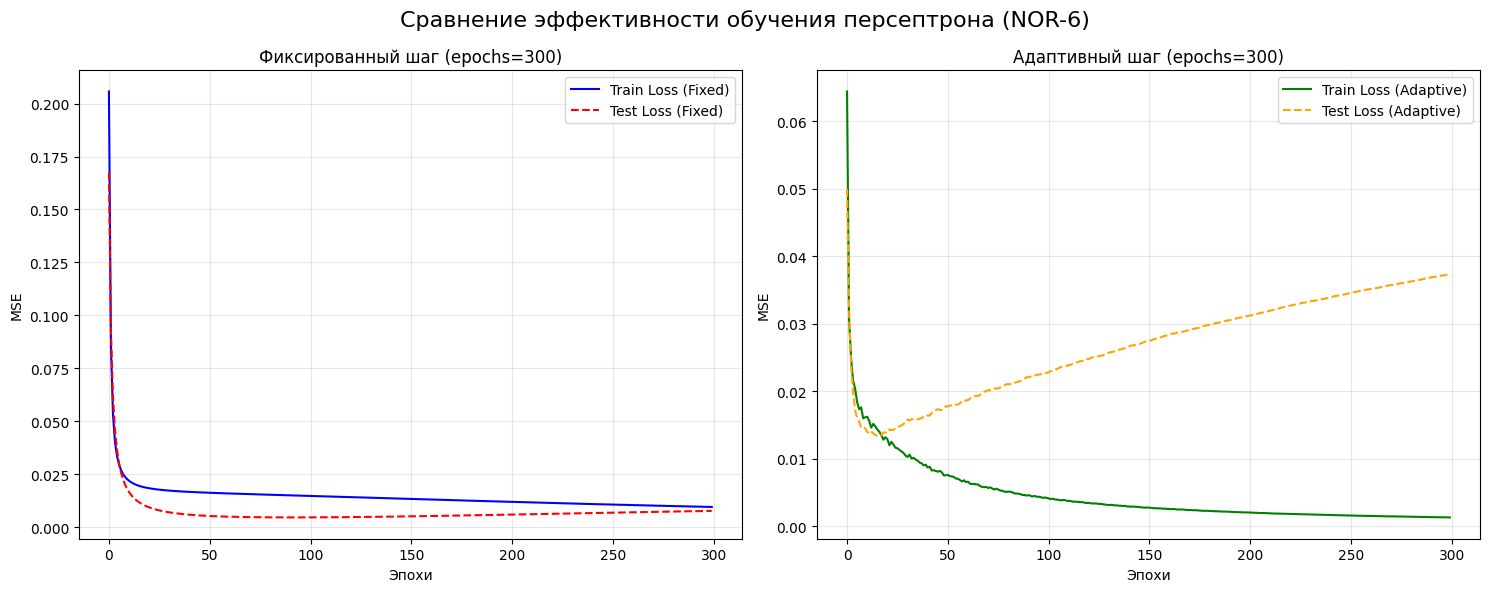

In [56]:
import matplotlib.pyplot as plt

def plot_results(train_fix, test_fix, train_ada, test_ada):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # График для фиксированного шага
    ax1.plot(train_fix, color='blue', label='Train Loss (Fixed)')
    ax1.plot(test_fix, color='red', linestyle='--', label='Test Loss (Fixed)')
    ax1.set_title(f'Фиксированный шаг (epochs={len(train_fix)})')
    ax1.set_xlabel('Эпохи')
    ax1.set_ylabel('MSE')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # График для адаптивного шага
    ax2.plot(train_ada, color='green', label='Train Loss (Adaptive)')
    ax2.plot(test_ada, color='orange', linestyle='--', label='Test Loss (Adaptive)')
    ax2.set_title(f'Адаптивный шаг (epochs={len(train_ada)})')
    ax2.set_xlabel('Эпохи')
    ax2.set_ylabel('MSE')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.suptitle('Сравнение эффективности обучения персептрона (NOR-6)', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_results(train_fix, test_fix, train_ada, test_ada)

In [62]:
loss_f, acc_f = model_fix.evaluate(x_test, y_test)
test_preds = (model_fix.predict(x_test) > 0.5).astype(float)
accuracy = np.mean(test_preds == y_test)
print(f"\nТочность на тестовых данных: {accuracy * 100:.2f}%")


Точность на тестовых данных: 100.00%


In [65]:
loss_f, acc_f = model_ada.evaluate(x_test, y_test)
test_preds = (model_ada.predict(x_test) > 0.5).astype(float)
accuracy = np.mean(test_preds == y_test)
print(f"\nТочность на тестовых данных: {accuracy * 100:.2f}%")


Точность на тестовых данных: 89.47%


In [63]:
model_fix.print_weights()


=== Итоговые параметры сети ===

Слой 1 (sigmoid):
Веса (W):
[[-1.45537791]
 [-1.62697958]
 [-1.69233498]
 [-0.70100898]
 [-1.31709665]
 [-1.09899877]]
Пороги (b): [-0.26061644]


In [64]:
model_ada.print_weights()


=== Итоговые параметры сети ===

Слой 1 (sigmoid):
Веса (W):
[[-4.06792544]
 [-4.04511736]
 [-4.07124713]
 [-1.34497227]
 [-4.02210828]
 [-1.60122426]]
Пороги (b): [1.7590679]


In [67]:
def run_inference_mode(model, n_inputs):
    print(f"\n=== РЕЖИМ ФУНКЦИОНИРОВАНИЯ (n = {n_inputs}) ===")
    print(f"Введите {n_inputs} чисел (0 или 1) через пробел.")
    print("Программа выдаст вероятность и итоговый логический класс.")
    print("Для выхода введите 'q'.")


    while True:
        user_input = input(f"\nВведите вектор переменных (например, {' '.join(['0']*n_inputs)}): ").strip()

        if user_input.lower() == 'q':
            break

        try:
            values = list(map(float, user_input.split()))

            if len(values) != n_inputs:
                print(f"Ошибка: ожидалось {n_inputs} значений, а введено {len(values)}.")
                continue

            point = np.array(values, dtype=np.float32).reshape(1, -1)

            prediction = model.predict(point)[0][0]
            cls = int(prediction > 0.5)

            print("-" * 40)
            print(f"Входной вектор: {values}")
            print(f"Вероятность (сигмоида): {prediction:.6f}")
            print(f"Результат (округленный): {cls}")
            print("-" * 40)

        except ValueError:
            print("Ошибка: вводите только числа 0 или 1 через пробел.")

n = 6
run_inference_mode(model_fix, n)


=== РЕЖИМ ФУНКЦИОНИРОВАНИЯ (n = 6) ===
Введите 6 чисел (0 или 1) через пробел.
Программа выдаст вероятность и итоговый логический класс.
Для выхода введите 'q'.

Введите вектор переменных (например, 0 0 0 0 0 0): 0 1 0 0 0 1
----------------------------------------
Входной вектор: [0.0, 1.0, 0.0, 0.0, 0.0, 1.0]
Вероятность (сигмоида): 0.048035
Результат (округленный): 0
----------------------------------------

Введите вектор переменных (например, 0 0 0 0 0 0): 1 1 1 1 1 1 
----------------------------------------
Входной вектор: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Вероятность (сигмоида): 0.000288
Результат (округленный): 0
----------------------------------------

Введите вектор переменных (например, 0 0 0 0 0 0): 0 0 0 0 0 1
----------------------------------------
Входной вектор: [0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
Вероятность (сигмоида): 0.204303
Результат (округленный): 0
----------------------------------------

Введите вектор переменных (например, 0 0 0 0 0 0): 0 0 0 0 0 0
--------------

In [68]:
run_inference_mode(model_ada, n)


=== РЕЖИМ ФУНКЦИОНИРОВАНИЯ (n = 6) ===
Введите 6 чисел (0 или 1) через пробел.
Программа выдаст вероятность и итоговый логический класс.
Для выхода введите 'q'.

Введите вектор переменных (например, 0 0 0 0 0 0): 0 1 0 0 0 1
----------------------------------------
Входной вектор: [0.0, 1.0, 0.0, 0.0, 0.0, 1.0]
Вероятность (сигмоида): 0.020089
Результат (округленный): 0
----------------------------------------

Введите вектор переменных (например, 0 0 0 0 0 0): 1 1 1 1 1 1 
----------------------------------------
Входной вектор: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Вероятность (сигмоида): 0.000000
Результат (округленный): 0
----------------------------------------

Введите вектор переменных (например, 0 0 0 0 0 0): 0 0 0 0 0 1
----------------------------------------
Входной вектор: [0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
Вероятность (сигмоида): 0.539379
Результат (округленный): 1
----------------------------------------

Введите вектор переменных (например, 0 0 0 0 0 0): q
